# 05 — Transferencia de dominio y adaptación de la cabeza logística

Este notebook estudia dos preguntas sobre el modelo entrenado en **RAVDESS Speech**:

1. ¿Cuánto generalizan sin adaptación el baseline eGeMAPS y el modelo final wav2vec `average_mean_std` sobre **RAVDESS Song** y **EMO-DB**?
2. ¿Cómo evoluciona la balanced accuracy cuando se actualiza únicamente la cabeza logística con cantidades crecientes de hablantes del dominio destino?

## Modelo congelado

En ambos pipelines se mantienen congelados:

- la extracción eGeMAPSv02 o wav2vec2;
- el pooling wav2vec `average_mean_std`;
- el `StandardScaler` ajustado en RAVDESS Speech.

Solo se actualizan los coeficientes e interceptos de la Logistic Regression de ocho salidas.

## Armonización de `boredom`

EMO-DB codifica `boredom`, clase ausente en RAVDESS. En este proyecto se armoniza operacionalmente:

```text
boredom → calm
```

La decisión se apoya en el bajo arousal compartido, pero no afirma equivalencia psicológica completa: `emotion_native` conserva `boredom` para auditar resultados y revisar posteriormente el supuesto de valence.

---
## 1 · Configuración y protocolo

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.contracts import (
    PARTITION_DEVELOPMENT,
    PARTITION_TEST_INDEPENDENT,
    TARGET_EMOTION_ORIGINAL,
)
from src.data.domain_datasets import (
    DATASET_EMODB,
    DATASET_RAVDESS_SONG,
    PARTITION_ADAPTATION,
    PARTITION_DOMAIN_TEST,
    load_or_build_domain_splits,
    load_or_prepare_domain_metadata,
)
from src.evaluation.domain_transfer import (
    build_domain_matrix,
    evaluate_zero_shot,
    rectangular_confusion,
    run_head_adaptation_curve,
    select_representative_max_run,
)
from src.features.domain_features import (
    align_domain_representations,
    extract_or_load_domain_representations,
)
from src.features.feature_store import (
    load_representation,
    prepare_model_table,
)
from src.features.wav2vec_temporal import (
    build_static_representation,
    load_layer_statistics,
)
from src.models.linear_head_adaptation import (
    initialize_head_from_sklearn,
    validate_head_equivalence,
)
from src.models.linear_probe import build_linear_probe
from src.utils.config import get_config, resolve_path
from src.utils.domain_transfer_visualization import (
    plot_rectangular_confusion,
    plot_source_retention,
    plot_target_learning_curves,
    plot_transfer_tradeoff,
    plot_zero_shot,
)
from src.utils.io import load_metadata, load_splits
from src.utils.reproducibility import set_global_seed

cfg = get_config()
set_global_seed(int(cfg.seed))

if str(cfg.metrics.primary) != "balanced_accuracy":
    raise ValueError(
        "Este notebook requiere balanced_accuracy como métrica primaria."
    )
if not hasattr(cfg, "domain_transfer"):
    raise ValueError(
        "Falta la sección domain_transfer en config.yaml. "
        "Copie configs/config_domain_transfer_patch.yaml."
    )

RUN_PREPROCESSING = False
RUN_FEATURE_EXTRACTION = False
RUN_ZERO_SHOT = True
RUN_ADAPTATION = True

SOURCE_LABELS = list(
    dict(cfg.emotion_mapping.code_to_name).values()
)
SOURCE_REPRESENTATIONS = (
    "egemaps",
    "wav2vec_temporal",
)

REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
FIGURES_DIR = resolve_path(cfg.paths.figures_dir)
PROCESSED_DOMAINS = resolve_path(
    cfg.domain_transfer.processed_root
)
for directory in (
    REPORTS_DIR,
    FIGURES_DIR,
    PROCESSED_DOMAINS,
):
    directory.mkdir(parents=True, exist_ok=True)

print("Métrica primaria:", cfg.metrics.primary)
print("Clases de salida:", SOURCE_LABELS)

Métrica primaria: balanced_accuracy
Clases de salida: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


Los tamaños de adaptación se expresan en **cantidad de hablantes**, no de audios. Para cada tamaño se repiten subconjuntos de speakers y semillas de optimización. Los tests de cada dominio permanecen fijos durante todo el notebook.

---
## 2 · Dominio fuente: reconstrucción de las dos cabezas

In [2]:
source_metadata = load_metadata(cfg.paths.metadata)
source_splits = load_splits(cfg.paths.splits)

source_egemaps = load_representation(
    "egemaps",
    cfg.paths.features_dir,
)
source_temporal_stats = load_layer_statistics(
    cfg.temporal_representation.layer_statistics_path,
    expected_file_ids=source_metadata["file_id"],
)
source_wav2vec = build_static_representation(
    source_temporal_stats,
    layer_strategy="average",
    pooling="mean_std",
)

source_representations = {
    "egemaps": source_egemaps,
    "wav2vec_temporal": source_wav2vec,
}

source_pipelines = {}
source_matrices = {
    PARTITION_DEVELOPMENT: {},
    PARTITION_TEST_INDEPENDENT: {},
}

for representation_name, representation in source_representations.items():
    dev_table, feature_columns = prepare_model_table(
        representation,
        source_metadata,
        source_splits,
        partition=PARTITION_DEVELOPMENT,
    )
    test_table, test_feature_columns = prepare_model_table(
        representation,
        source_metadata,
        source_splits,
        partition=PARTITION_TEST_INDEPENDENT,
    )
    if feature_columns != test_feature_columns:
        raise ValueError(
            f"Orden de features inconsistente: {representation_name}"
        )

    pipeline = build_linear_probe(
        params=dict(cfg.models.logistic_regression),
        seed=int(cfg.seed),
    )
    pipeline.fit(
        dev_table[feature_columns].to_numpy("float32"),
        dev_table[TARGET_EMOTION_ORIGINAL].astype(str),
    )
    source_pipelines[representation_name] = pipeline

    source_matrices[PARTITION_DEVELOPMENT][representation_name] = {
        "table": dev_table,
        "feature_columns": feature_columns,
    }
    source_matrices[PARTITION_TEST_INDEPENDENT][representation_name] = {
        "table": test_table,
        "feature_columns": feature_columns,
    }

    copied_head = initialize_head_from_sklearn(pipeline)
    max_difference = validate_head_equivalence(
        pipeline,
        copied_head,
        test_table[feature_columns].to_numpy("float32")[:64],
    )
    print(
        representation_name,
        "· copia sklearn→PyTorch:",
        f"{max_difference:.2e}",
    )

2026-07-05 14:29:05 | INFO     | src.features.feature_store | Cargado 'egemaps': 1440 muestras, 88 features.
egemaps · copia sklearn→PyTorch: 7.75e-07
wav2vec_temporal · copia sklearn→PyTorch: 2.68e-06


La validación anterior comprueba que la capa lineal PyTorch reproduce las probabilidades del pipeline sklearn antes de adaptar. Por lo tanto, cualquier cambio posterior proviene de la actualización de la cabeza y no de una implementación diferente del zero-shot.

---
## 3 · Metadata, trimming y splits de los dominios

In [3]:
DOMAIN_PATHS = {
    DATASET_RAVDESS_SONG: {
        "raw": resolve_path(cfg.domain_transfer.raw.ravdess_song),
        "root": PROCESSED_DOMAINS / DATASET_RAVDESS_SONG,
    },
    DATASET_EMODB: {
        "raw": resolve_path(cfg.domain_transfer.raw.emodb),
        "root": PROCESSED_DOMAINS / DATASET_EMODB,
    },
}

domain_metadata = {}
domain_splits = {}

if RUN_PREPROCESSING:
    for dataset, paths in DOMAIN_PATHS.items():
        root = paths["root"]
        metadata = load_or_prepare_domain_metadata(
            dataset=dataset,
            raw_dir=paths["raw"],
            audio_trimmed_dir=root / "audio_trimmed",
            metadata_path=root / "metadata.parquet",
            sample_rate=int(
                cfg.domain_transfer.audio.output_sample_rate
            ),
            frame_length_ms=float(cfg.audio.frame_length_ms),
            hop_length_ms=float(cfg.audio.hop_length_ms),
            threshold_db=float(cfg.audio.threshold_db),
            padding_ms=float(cfg.audio.padding_ms),
            trim_ratio_warning=float(
                cfg.audio.trim_ratio_warning
            ),
            overwrite_metadata=False,
            overwrite_audio=False,
        )

        splits = load_or_build_domain_splits(
            metadata,
            output_path=root / "splits.parquet",
            dataset=dataset,
            source_test_actors=(
                list(cfg.splits.test_independent_actors)
                if dataset == DATASET_RAVDESS_SONG
                else None
            ),
            emodb_test_speakers=(
                None
                if cfg.domain_transfer.emodb.test_speakers is None
                else list(cfg.domain_transfer.emodb.test_speakers)
            ),
            n_emodb_test_speakers=int(
                cfg.domain_transfer.emodb.n_test_speakers
            ),
            seed=int(cfg.seed),
            overwrite=False,
        )
        domain_metadata[dataset] = metadata
        domain_splits[dataset] = splits
else:
    for dataset, paths in DOMAIN_PATHS.items():
        domain_metadata[dataset] = pd.read_parquet(
            paths["root"] / "metadata.parquet"
        )
        domain_splits[dataset] = pd.read_parquet(
            paths["root"] / "splits.parquet"
        )

domain_overview = []
for dataset in DOMAIN_PATHS:
    merged = domain_metadata[dataset].merge(
        domain_splits[dataset],
        on="file_id",
        validate="one_to_one",
    )
    for partition, group in merged.groupby(
        "partition",
        observed=True,
    ):
        domain_overview.append(
            {
                "dataset": dataset,
                "partition": partition,
                "n_audios": len(group),
                "n_speakers": group["speaker_id"].nunique(),
                "speakers": sorted(group["speaker_id"].unique()),
                "labels_canonical": sorted(
                    group["emotion_original"].unique()
                ),
                "labels_native": sorted(
                    group["emotion_native"].unique()
                ),
            }
        )

display(pd.DataFrame(domain_overview))

,dataset,partition,n_audios,n_speakers,speakers,labels_canonical,labels_native
0,ravdess_song,adaptation_pool,836,19,"[ravdess_01, ravdess_03, ravdess_04, ravdess_0...","[angry, calm, fearful, happy, neutral, sad]","[angry, calm, fearful, happy, neutral, sad]"
1,ravdess_song,domain_test,176,4,"[ravdess_02, ravdess_06, ravdess_21, ravdess_23]","[angry, calm, fearful, happy, neutral, sad]","[angry, calm, fearful, happy, neutral, sad]"
2,emodb,adaptation_pool,405,8,"[emodb_03, emodb_08, emodb_09, emodb_10, emodb...","[angry, calm, disgust, fearful, happy, neutral...","[angry, boredom, disgust, fearful, happy, neut..."
3,emodb,domain_test,130,2,"[emodb_13, emodb_14]","[angry, calm, disgust, fearful, happy, neutral...","[angry, boredom, disgust, fearful, happy, neut..."


RAVDESS Song hereda los cuatro actores del test de RAVDESS Speech. EMO-DB selecciona dos speakers una única vez maximizando cobertura de clases; el split se persiste y no vuelve a elegirse según los resultados.

Los audios destino se guardan a la misma frecuencia de trabajo que RAVDESS procesado para reducir un cambio técnico evitable antes de extraer eGeMAPS. wav2vec vuelve a consumir 16 kHz mediante su feature extractor oficial.

---
## 4 · Extracción de features y alineación

In [4]:
domain_representations = {}

if RUN_FEATURE_EXTRACTION:
    for dataset, paths in DOMAIN_PATHS.items():
        extracted = extract_or_load_domain_representations(
            domain_metadata[dataset],
            features_dir=paths["root"] / "features",
            model_name=str(cfg.features.wav2vec.model_name),
            revision=str(cfg.features.wav2vec.revision),
            target_sample_rate=int(cfg.audio.target_sample_rate),
            include_feature_projection=bool(
                cfg.temporal_representation.include_feature_projection
            ),
            sequence_dtype=str(
                cfg.temporal_representation.sequence_dtype
            ),
            overwrite=False,
        )
        domain_representations[dataset] = (
            align_domain_representations(
                source_representations,
                extracted,
            )
        )
else:
    for dataset, paths in DOMAIN_PATHS.items():
        egemaps = pd.read_parquet(
            paths["root"] / "features" / "egemaps.parquet"
        )
        stats = load_layer_statistics(
            paths["root"]
            / "features"
            / "wav2vec_layer_statistics.npz",
            expected_file_ids=domain_metadata[dataset]["file_id"],
        )
        extracted = {
            "egemaps": egemaps,
            "wav2vec_temporal": build_static_representation(
                stats,
                layer_strategy="average",
                pooling="mean_std",
            ),
        }
        domain_representations[dataset] = (
            align_domain_representations(
                source_representations,
                extracted,
            )
        )

for dataset, representations in domain_representations.items():
    print(dataset)
    for name, frame in representations.items():
        print(" ", name, frame.shape)

ravdess_song
  egemaps (1012, 89)
  wav2vec_temporal (1012, 1537)
emodb
  egemaps (535, 89)
  wav2vec_temporal (535, 1537)


La alineación exige exactamente los mismos nombres y el mismo orden de features que en RAVDESS Speech. No se reajusta el extractor ni se proyectan las variables destino a otro espacio.

---
## 5 · Matrices de adaptation pool y target test

In [5]:
target_matrices = {}

for dataset in DOMAIN_PATHS:
    target_matrices[dataset] = {
        PARTITION_ADAPTATION: {},
        PARTITION_DOMAIN_TEST: {},
    }

    for representation_name, representation in (
        domain_representations[dataset].items()
    ):
        for partition in (
            PARTITION_ADAPTATION,
            PARTITION_DOMAIN_TEST,
        ):
            table, feature_columns = prepare_model_table(
                representation,
                domain_metadata[dataset],
                domain_splits[dataset],
                partition=partition,
            )
            target_matrices[dataset][partition][
                representation_name
            ] = build_domain_matrix(
                table,
                feature_columns,
            )

display(
    pd.DataFrame(
        [
            {
                "dataset": dataset,
                "partition": partition,
                "representation": representation,
                "n_samples": len(matrix.y),
                "n_speakers": len(set(matrix.speaker_ids)),
                "labels": sorted(set(matrix.y)),
            }
            for dataset, partition_data in target_matrices.items()
            for partition, representations in partition_data.items()
            for representation, matrix in representations.items()
        ]
    )
)

,dataset,partition,representation,n_samples,n_speakers,labels
0,ravdess_song,adaptation_pool,egemaps,836,19,"[angry, calm, fearful, happy, neutral, sad]"
1,ravdess_song,adaptation_pool,wav2vec_temporal,836,19,"[angry, calm, fearful, happy, neutral, sad]"
2,ravdess_song,domain_test,egemaps,176,4,"[angry, calm, fearful, happy, neutral, sad]"
3,ravdess_song,domain_test,wav2vec_temporal,176,4,"[angry, calm, fearful, happy, neutral, sad]"
4,emodb,adaptation_pool,egemaps,405,8,"[angry, calm, disgust, fearful, happy, neutral..."
5,emodb,adaptation_pool,wav2vec_temporal,405,8,"[angry, calm, disgust, fearful, happy, neutral..."
6,emodb,domain_test,egemaps,130,2,"[angry, calm, disgust, fearful, happy, neutral..."
7,emodb,domain_test,wav2vec_temporal,130,2,"[angry, calm, disgust, fearful, happy, neutral..."


---
## 6 · Zero-shot de las cabezas RAVDESS

,domain,representation,stage,n_adaptation_speakers,n_adaptation_samples,repeat,seed,run_id,balanced_accuracy,macro_f1_observed,macro_f1_source_space,accuracy,unsupported_prediction_rate,n_unsupported_prediction_classes,n_samples,n_observed_classes
3,emodb,wav2vec_temporal,zero_shot,0,0,-1,-1,zero_shot::emodb::wav2vec_temporal,0.483,0.415,0.363,0.469,0.008,1,130,7
2,emodb,egemaps,zero_shot,0,0,-1,-1,zero_shot::emodb::egemaps,0.217,0.163,0.143,0.285,0.100,1,130,7
1,ravdess_song,wav2vec_temporal,zero_shot,0,0,-1,-1,zero_shot::ravdess_song::wav2vec_temporal,0.458,0.397,0.297,0.460,0.006,1,176,6
0,ravdess_song,egemaps,zero_shot,0,0,-1,-1,zero_shot::ravdess_song::egemaps,0.349,0.320,0.240,0.381,0.074,1,176,6


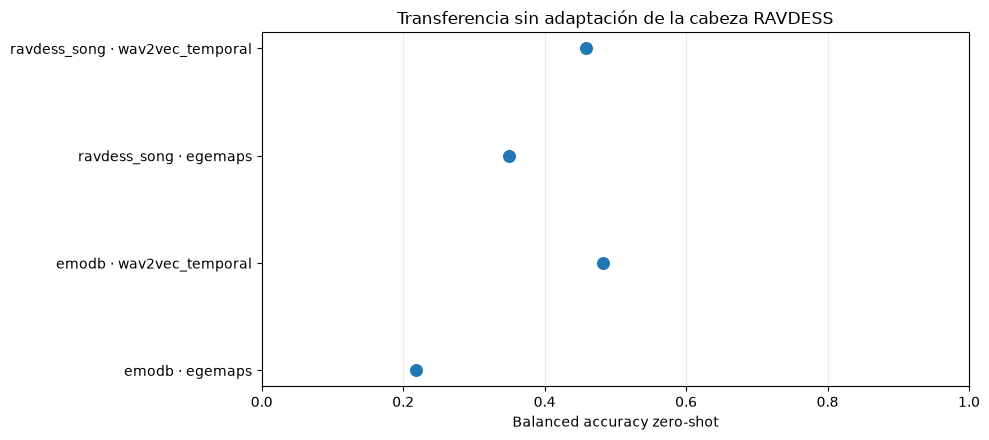

In [6]:
zero_shot_tests = {
    dataset: target_matrices[dataset][PARTITION_DOMAIN_TEST]
    for dataset in DOMAIN_PATHS
}

if RUN_ZERO_SHOT:
    zero_shot_results, zero_shot_predictions = evaluate_zero_shot(
        source_pipelines,
        zero_shot_tests,
        source_labels=SOURCE_LABELS,
    )
    zero_shot_results.to_csv(
        resolve_path(
            cfg.domain_transfer.artifacts.zero_shot_results
        ),
        index=False,
    )
else:
    zero_shot_results = pd.read_csv(
        resolve_path(
            cfg.domain_transfer.artifacts.zero_shot_results
        )
    )
    zero_shot_predictions = pd.DataFrame()

display(
    zero_shot_results.sort_values(
        ["domain", "balanced_accuracy"],
        ascending=[True, False],
    ).style.format(
        {
            "balanced_accuracy": "{:.3f}",
            "macro_f1_observed": "{:.3f}",
            "macro_f1_source_space": "{:.3f}",
            "accuracy": "{:.3f}",
            "unsupported_prediction_rate": "{:.3f}",
        }
    )
)

fig, _ = plot_zero_shot(zero_shot_results)
fig.savefig(
    FIGURES_DIR / "domain_transfer_zero_shot.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

La balanced accuracy se calcula explícitamente como el recall macro de las clases realmente presentes en `y_true`. Esta formulación es equivalente a `balanced_accuracy_score` para el protocolo actual, pero no genera warnings cuando la cabeza de ocho salidas predice una clase sin soporte en el target.

Una predicción hacia una categoría RAVDESS ausente —por ejemplo `surprised` en EMO-DB— sigue contando como falso negativo de la clase verdadera, reduce su recall y queda resumida además en `unsupported_prediction_rate`.

`macro_f1_observed` promedia solo sobre clases target observadas. `macro_f1_source_space` conserva las ocho etiquetas de la cabeza y es deliberadamente más severa cuando faltan clases en el dominio.

---
## 7 · Matrices rectangulares zero-shot

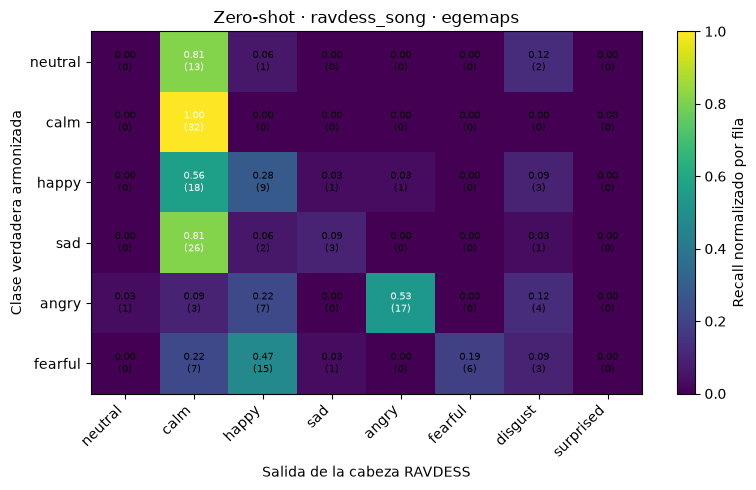

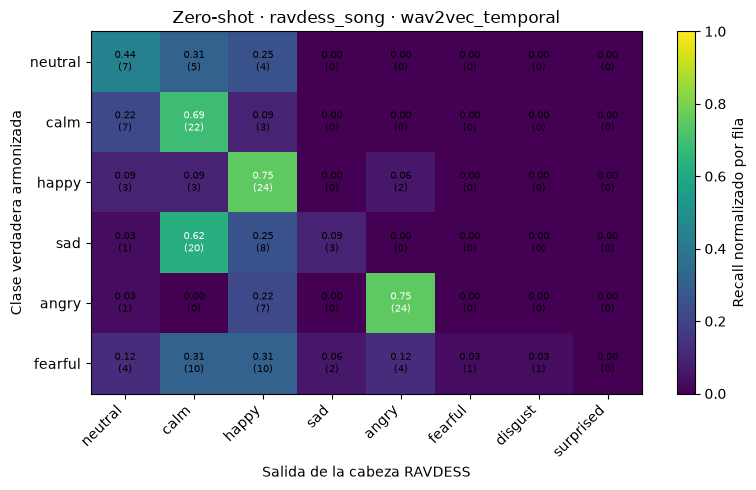

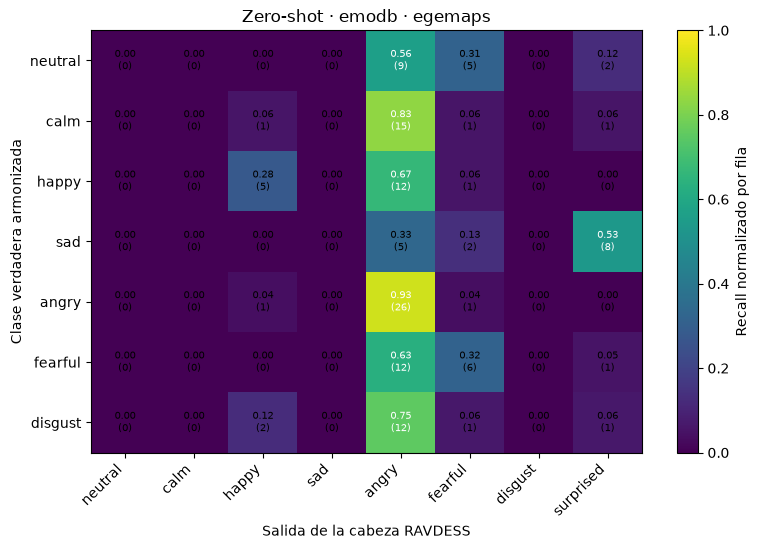

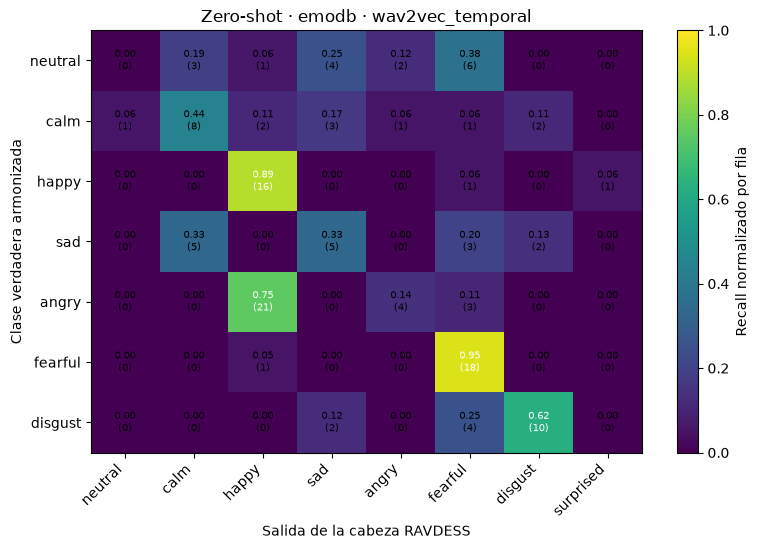

In [7]:
if zero_shot_predictions.empty:
    print(
        "No se cargaron predicciones zero-shot. "
        "Ejecute RUN_ZERO_SHOT=True para generar matrices."
    )
else:
    for dataset in DOMAIN_PATHS:
        for representation in SOURCE_REPRESENTATIONS:
            selected = zero_shot_predictions.loc[
                zero_shot_predictions["domain"].eq(dataset)
                & zero_shot_predictions[
                    "representation"
                ].eq(representation)
            ]
            counts, normalized, rows, columns = (
                rectangular_confusion(
                    selected,
                    source_labels=SOURCE_LABELS,
                )
            )
            fig, _ = plot_rectangular_confusion(
                counts,
                normalized,
                rows,
                columns,
                title=(
                    f"Zero-shot · {dataset} · "
                    f"{representation}"
                ),
            )
            fig.savefig(
                FIGURES_DIR
                / f"zero_shot_cm_{dataset}_{representation}.png",
                dpi=150,
                bbox_inches="tight",
            )
            plt.show()

Las filas corresponden a clases verdaderas armonizadas del dominio destino y las ocho columnas a salidas posibles de la cabeza RAVDESS. Así se conservan explícitamente categorías sin soporte en el target, sin introducir filas artificiales con denominador cero.

---
## 8 · Curvas de adaptación de la cabeza

In [8]:
source_test_matrices = {}
for representation_name in SOURCE_REPRESENTATIONS:
    source_test_info = source_matrices[
        PARTITION_TEST_INDEPENDENT
    ][representation_name]
    source_test_table = source_test_info["table"].copy()
    source_test_table["speaker_id"] = source_test_table[
        "actor_id"
    ].map(lambda value: f"ravdess_{int(value):02d}")
    source_test_table["emotion_native"] = source_test_table[
        TARGET_EMOTION_ORIGINAL
    ]
    source_test_matrices[representation_name] = build_domain_matrix(
        source_test_table,
        source_test_info["feature_columns"],
    )

adaptation_frames = []
adaptation_prediction_frames = []

if RUN_ADAPTATION:
    for dataset in DOMAIN_PATHS:
        for representation in SOURCE_REPRESENTATIONS:
            results, predictions = run_head_adaptation_curve(
                domain=dataset,
                representation=representation,
                source_pipeline=source_pipelines[representation],
                adaptation_pool=target_matrices[dataset][
                    PARTITION_ADAPTATION
                ][representation],
                target_test=target_matrices[dataset][
                    PARTITION_DOMAIN_TEST
                ][representation],
                source_test=source_test_matrices[representation],
                source_labels=SOURCE_LABELS,
                speaker_sizes=list(
                    cfg.domain_transfer.adaptation.speaker_sizes
                ),
                repeats=int(
                    cfg.domain_transfer.adaptation.subset_repeats
                ),
                optimization_seeds=list(
                    cfg.domain_transfer.adaptation.optimization_seeds
                ),
                subset_seed=int(cfg.seed),
                learning_rate=float(
                    cfg.domain_transfer.adaptation.learning_rate
                ),
                epochs=int(
                    cfg.domain_transfer.adaptation.epochs
                ),
                batch_size=int(
                    cfg.domain_transfer.adaptation.batch_size
                ),
                weight_decay=float(
                    cfg.domain_transfer.adaptation.weight_decay
                ),
                source_anchor=float(
                    cfg.domain_transfer.adaptation.source_anchor
                ),
            )
            adaptation_frames.append(results)
            adaptation_prediction_frames.append(predictions)

    adaptation_results = pd.concat(
        adaptation_frames,
        ignore_index=True,
        sort=False,
    )
    adaptation_predictions = pd.concat(
        adaptation_prediction_frames,
        ignore_index=True,
        sort=False,
    )
    adaptation_results.to_csv(
        resolve_path(
            cfg.domain_transfer.artifacts.adaptation_results
        ),
        index=False,
    )
    adaptation_predictions.to_csv(
        resolve_path(
            cfg.domain_transfer.artifacts.predictions
        ),
        index=False,
    )
else:
    adaptation_results = pd.read_csv(
        resolve_path(
            cfg.domain_transfer.artifacts.adaptation_results
        )
    )
    adaptation_predictions = pd.read_csv(
        resolve_path(
            cfg.domain_transfer.artifacts.predictions
        )
    )

curve_summary = (
    adaptation_results.groupby(
        [
            "domain",
            "representation",
            "n_adaptation_speakers",
        ],
        observed=True,
        as_index=False,
    )[
        [
            "target_balanced_accuracy",
            "source_balanced_accuracy",
            "target_gain",
            "source_change",
            "unsupported_prediction_rate",
        ]
    ]
    .agg(["mean", "std", "count"])
)

display(curve_summary)

domain    representation n_adaptation_speakers  \
                                                           
0          emodb           egemaps                     0   
1          emodb           egemaps                     1   
2          emodb           egemaps                     2   
3          emodb           egemaps                     4   
4          emodb           egemaps                     8   
5          emodb  wav2vec_temporal                     0   
6          emodb  wav2vec_temporal                     1   
7          emodb  wav2vec_temporal                     2   
8          emodb  wav2vec_temporal                     4   
9          emodb  wav2vec_temporal                     8   
10  ravdess_song           egemaps                     0   
11  ravdess_song           egemaps                     1   
12  ravdess_song           egemaps                     2   
13  ravdess_song           egemaps                     4   
14  ravdess_song           egemaps                     8   
15  ravdess_song           egemaps                    19   
16  ravdess_song  wav2vec_temporal                     0   
17  ravdess_song  wav2vec_temporal                     1   
18  ravdess_song  wav2vec_temporal                     2   
19  ravdess_song  wav2vec_temporal                     4   
20  ravdess_song  wav2vec_temporal                     8   
21  ravdess_song  wav2vec_temporal                    19   

   target_balanced_accuracy                 source_balanced_accuracy  \
                       mean       std count                     mean   
0                  0.217448       NaN     1                 0.554688   
1                  0.431789  0.041769    15                 0.535156   
2                  0.493959  0.012677    15                 0.496875   
3                  0.574808  0.021059    15                 0.468229   
4                  0.597410  0.008842     3                 0.458333   
5                  0.483127       NaN     1                 0.828125   
6                  0.693623  0.026364    15                 0.787500   
7                  0.779066  0.030606    15                 0.790885   
8                  0.835525  0.022338    15                 0.798177   
9                  0.874858  0.000000     3                 0.786458   
10                 0.348958       NaN     1                 0.554688   
11                 0.388542  0.041143    15                 0.507812   
12                 0.376042  0.018800    15                 0.505990   
13                 0.411806  0.028829    15                 0.500521   
14                 0.447222  0.031734    15                 0.511719   
15                 0.487847  0.007956     3                 0.511719   
16                 0.458333       NaN     1                 0.828125   
17                 0.504167  0.035336    15                 0.767969   
18                 0.521875  0.035826    15                 0.764062   
19                 0.585764  0.046787    15                 0.735156   
20                 0.600000  0.019607    15                 0.751823   
21                 0.638889  0.003007     3                 0.763021   

                   target_gain                 source_change                  \
         std count        mean       std count          mean       std count   
0        NaN     1    0.000000       NaN     1      0.000000       NaN     1   
1   0.024661    15    0.214341  0.041769    15     -0.019531  0.024661    15   
2   0.015499    15    0.276510  0.012677    15     -0.057813  0.015499    15   
3   0.014228    15    0.357360  0.021059    15     -0.086458  0.014228    15   
4   0.005967     3    0.379961  0.008842     3     -0.096354  0.005967     3   
5        NaN     1    0.000000       NaN     1      0.000000       NaN     1   
6   0.017078    15    0.210496  0.026364    15     -0.040625  0.017078    15   
7   0.007213    15    0.295938  0.030606    15     -0.037240  0.007213    15   
8   0.003189    15    0.352398  0.022338

Cada punto adaptado parte nuevamente de la cabeza fuente. No se continúa desde el tamaño anterior, por lo que la curva mide el efecto de la cantidad de hablantes y no una trayectoria acumulativa.

El scaler permanece congelado. En consecuencia, la pregunta experimental es estricta: **cuántos hablantes necesita una cabeza lineal para reorganizar un espacio acústico fijo frente al domain shift**.

---
## 9 · Evolución target y retención fuente

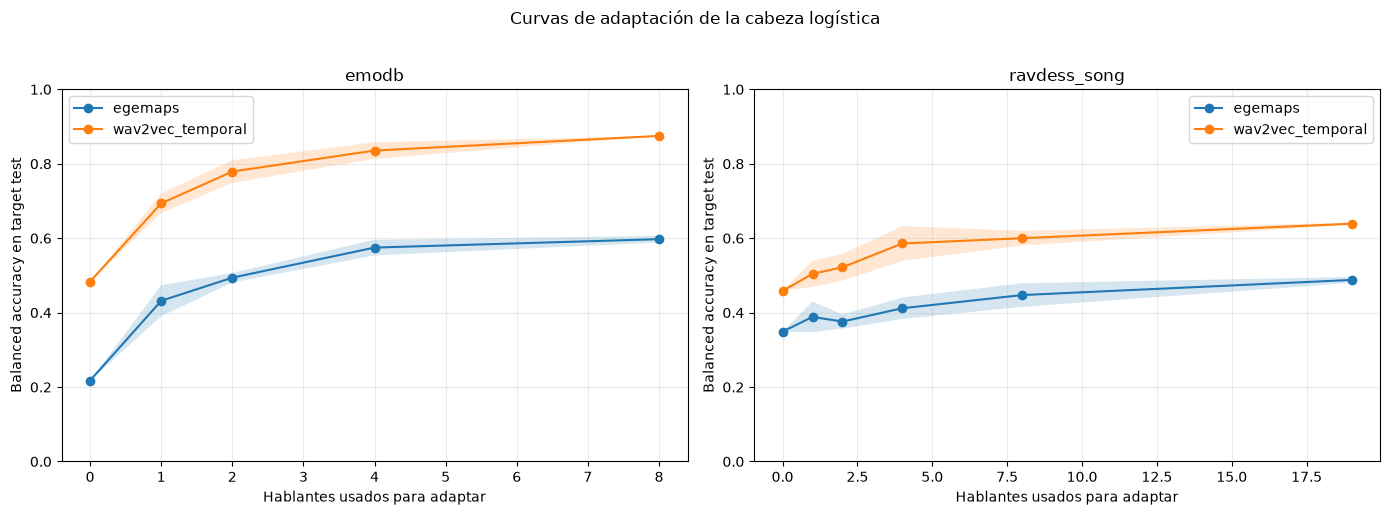

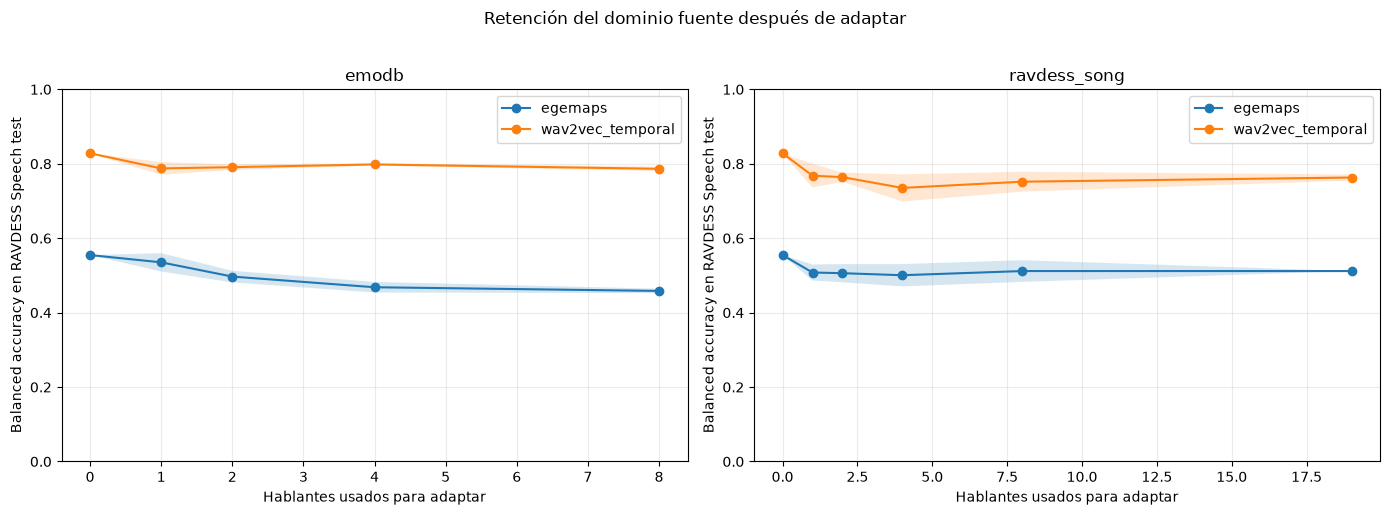

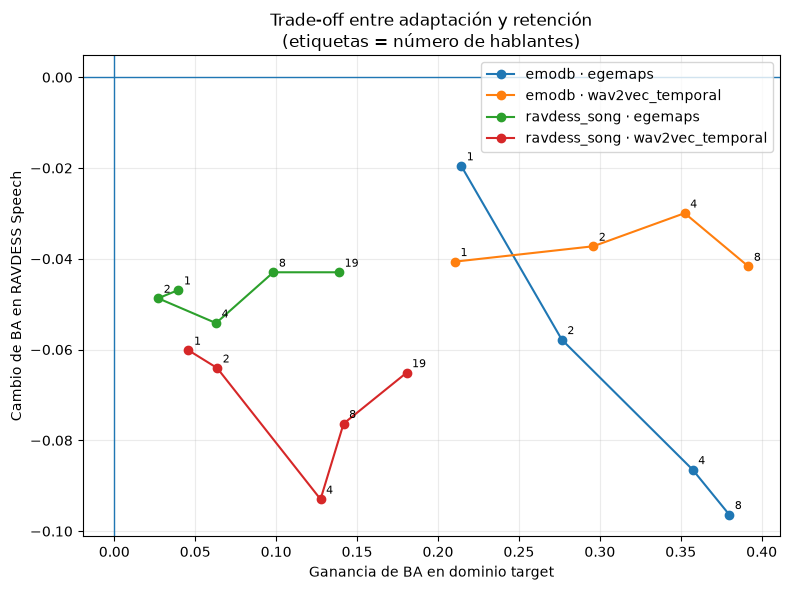

In [9]:
fig, _ = plot_target_learning_curves(adaptation_results)
fig.savefig(
    FIGURES_DIR / "domain_transfer_learning_curves.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

fig, _ = plot_source_retention(adaptation_results)
fig.savefig(
    FIGURES_DIR / "domain_transfer_source_retention.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

fig, _ = plot_transfer_tradeoff(adaptation_results)
fig.savefig(
    FIGURES_DIR / "domain_transfer_tradeoff.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

La primera figura mide adaptación al target. La segunda muestra si el mismo cambio conserva el reconocimiento de RAVDESS Speech. El trade-off evita declarar una mejora útil cuando solo se obtiene especialización a costa de una pérdida desproporcionada en el dominio fuente.

---
## 10 · Matrices del máximo tamaño de adaptación

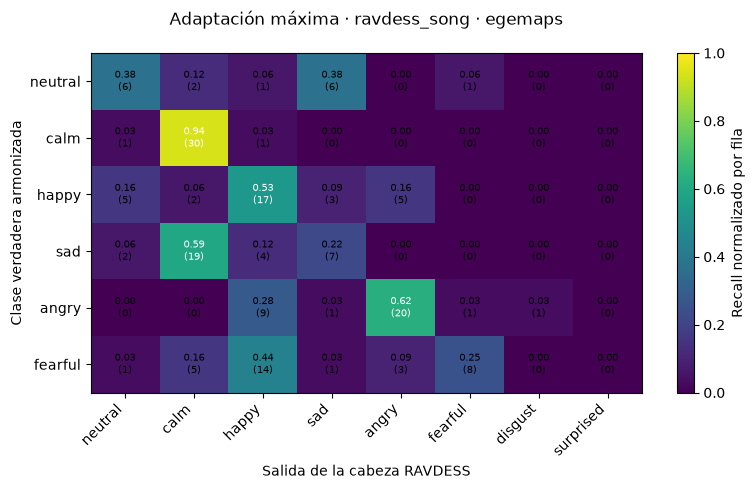

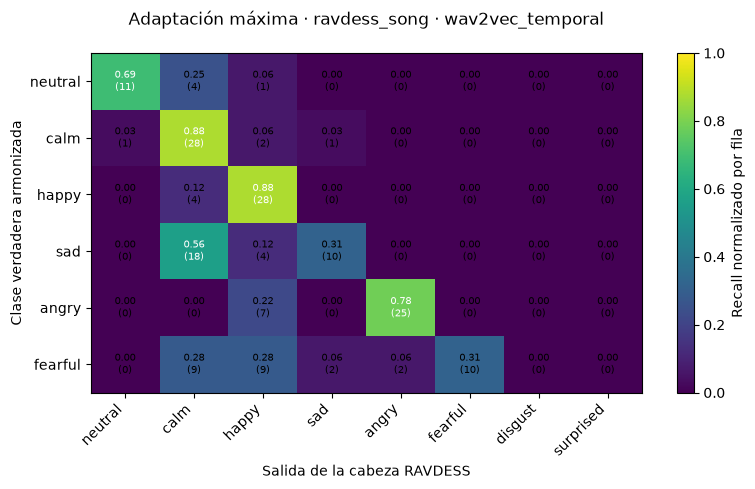

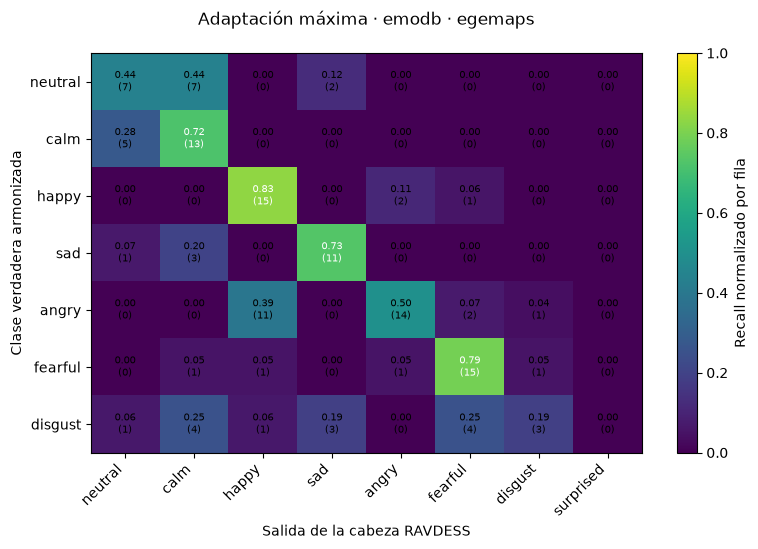

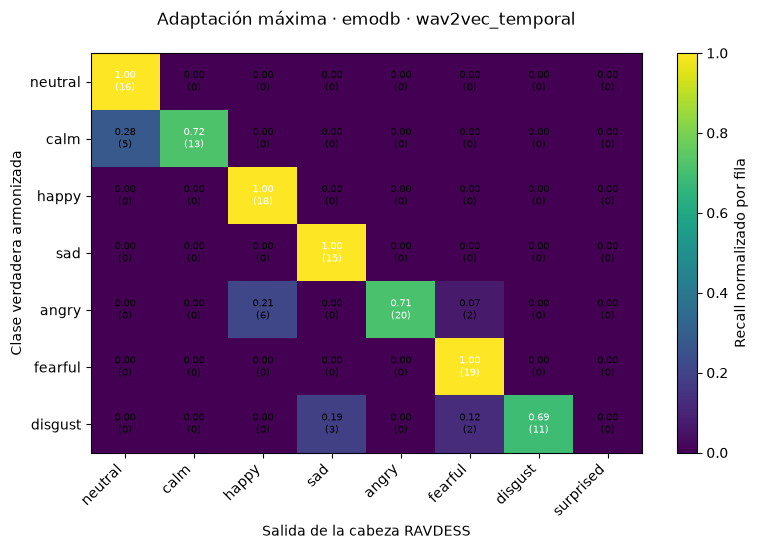

In [10]:
for dataset in DOMAIN_PATHS:
    for representation in SOURCE_REPRESENTATIONS:
        representative_run = select_representative_max_run(
            adaptation_results,
            domain=dataset,
            representation=representation,
        )
        selected = adaptation_predictions.loc[
            adaptation_predictions["run_id"].eq(
                representative_run
            )
        ]
        counts, normalized, rows, columns = (
            rectangular_confusion(
                selected,
                source_labels=SOURCE_LABELS,
            )
        )
        fig, _ = plot_rectangular_confusion(
            counts,
            normalized,
            rows,
            columns,
            title=(
                f"Adaptación máxima · {dataset} · "
                f"{representation}\n"
            ),
        )
        fig.savefig(
            FIGURES_DIR
            / f"adapted_cm_{dataset}_{representation}.png",
            dpi=150,
            bbox_inches="tight",
        )
        plt.show()

El run mostrado no es el mejor: es el más cercano a la balanced accuracy media entre ejecuciones con el máximo número de hablantes. Esto evita seleccionar visualmente un caso excepcionalmente favorable.

---
## Conclusiones

La representación wav2vec_temporal mostró una capacidad de transferencia sustancialmente superior a eGeMAPS frente a cambios de dominio. Sin observar ejemplos del dominio target, alcanzó mayor balanced accuracy tanto en RAVDESS Song como en EMO-DB, lo que indica que conserva una estructura emocional más transportable. La adaptación con un hablante mejoró en promedio el rendimiento zero-shot en los cuatro pares dominio-representación, aunque la ganancia no fue uniforme en todas las selecciones de hablantes. En EMO-DB, wav2vec presentó además el trade-off más favorable entre ganancia target y retención del dominio fuente, alcanzando mejoras superiores a 35 puntos con pérdidas cercanas a 3–4 puntos en RAVDESS Speech. La tasa de predicciones hacia clases sin soporte fue prácticamente nula. Esto indica que el deterioro no se debe principalmente a que el modelo concentre sus predicciones en emociones inexistentes en el dominio target. Sin embargo, esta observación no permite descartar cambios en la prevalencia de clases ni otras formas de label shift o conditional shift. El mapeo boredom → calm resultó parcialmente válido, aunque las confusiones con neutral y sad muestran que no constituye una equivalencia exacta. En consecuencia, wav2vec_temporal es una representación SSL con capacidad generalizadora y sería interesante la comparación con un modelo log-Mel CNN–LSTM, un state-of-the-art robusto.